In [1]:
import numpy as np
import sys,os
import scipy.special as sysp
import scipy.signal as sysig
import scipy.linalg as linalg
from pathlib import Path

Base_Dir = './' # assuming we are in zeldovich-smearing/examples/, else modify this
Like_Dir = Base_Dir + '../code/'
sys.path.append(Like_Dir)

from paths import *
sys.path.append(ML_Path)
from mlalgos import BiSequential
from mllib import Utilities

import copy,pickle,json

import gc
from time import time

ut = Utilities()

In [2]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib as mpl
import matplotlib.colors as pltcol

from cobaya.model import get_model

from getdist.mcsamples import loadMCSamples
%matplotlib inline  
import getdist.plots as gdplt

mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['legend.fontsize'] = 16 # 14
mpl.rcParams['legend.labelspacing'] = 0.25

FS = 18
FS2 = 15
FS3 = 13
FSL = 22

mpl.rcParams['xtick.major.size'] = 6
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['ytick.major.size'] = 6
mpl.rcParams['ytick.minor.size'] = 3
print('mpl setup done')
#mpl.rcParams.keys()

mpl setup done


***
# BAO Multipole Models
### Theoretical exploration of Zel'dovich smearing model
***

## Setup

### Configuration setup

In [3]:
Sample = 'DESI-LRG2' # one of '','DESI-LRG2' or 'Euclid-ELG'
Model_AP = True # can be True only if Sample != ''
Include_Sig2Obs = True 
L_Max = 3

if (Sample == '') & Model_AP:
    print('Model_AP not available for toy model. Setting to False.')
    Model_AP = False

### Files and folders

In [16]:
config_dict = {'DESI-LRG2': {'redshift':0.80,'Mmin':8e12,'phase':0,
                             'sample_root':'AbacusSummit/base_c000/'},
               'Euclid-ELG':{'redshift':1.10,'Mmin':1e12,'phase':1,
                             'sample_root':'AbacusSummit/base_c000/'},
               '':{'redshift':0.7,'Mmin':None,'sample_root':'SDBMC'}}

Redshift = config_dict[Sample]['redshift'] # 0.8 if Sample != '' else 0.7
M_min = config_dict[Sample]['Mmin']
Sample_Root = config_dict[Sample]['sample_root']

File_Tail = 'lgMmin{0:.2f}_z{1:.3f}'.format(np.log10(M_min),Redshift) if Sample != '' else 'sdbmc'

if File_Tail == 'sdbmc':
    Iteration = 2 # no iterations needed for sdbmc toy model

Plots_Dir = Base_Dir + 'plots/'
Plots_Dir += Sample_Root + Sample + '/'
print('   Plots dir   : ',Plots_Dir)
Path(Plots_Dir).mkdir(parents=True,exist_ok=True) # folder to store plots

# Basis_Root imported from paths
Basis_Prior_File = Basis_Root + 'fitcoeffs/biNN2p-LGbs.json'
Cosmo_Prior_File = Basis_Root + 'fitcoeffs/biNN2p-cosmo-s.json'

File_Body = '_LMax{0:d}_'.format(L_Max) + File_Tail
Data_Dir = Base_Dir + 'data/'
Scales_File = Data_Dir + Sample_Root + Sample + '/xi' + File_Body + '_scales.txt'

Data_File_XiLin = Data_Dir + Sample_Root + Sample + '/xilin.txt'

Data_File_Xi = Data_Dir + Sample_Root + Sample + '/xi' + File_Body + '.txt'
Cov_File = Data_Dir + Sample_Root + Sample + '/covmat' + File_Body 
if Include_Sig2Obs:
    Data_File_Sig2Obs = Data_Dir + Sample_Root + Sample + '/Sig2obs' + File_Body + '.txt'
    Data_File = copy.deepcopy([Data_File_Sig2Obs,Data_File_Xi])
    Cov_File += '_inclSig2obs'
else:
    Data_File = Data_File_Xi
if Model_AP:
    Cov_File += '_AP'
Cov_File += '.txt'

print(' Scales file   : ',Scales_File)
print('   Data file(s): ',Data_File)
print('Cov mat file   : ',Cov_File)

   Plots dir   :  ./plots/AbacusSummit/base_c000/DESI-LRG2/
 Scales file   :  ./data/AbacusSummit/base_c000/DESI-LRG2/xi_LMax3_lgMmin12.90_z0.800_scales.txt
   Data file(s):  ['./data/AbacusSummit/base_c000/DESI-LRG2/Sig2obs_LMax3_lgMmin12.90_z0.800.txt', './data/AbacusSummit/base_c000/DESI-LRG2/xi_LMax3_lgMmin12.90_z0.800.txt']
Cov mat file   :  ./data/AbacusSummit/base_c000/DESI-LRG2/covmat_LMax3_lgMmin12.90_z0.800_inclSig2obs_AP.txt


### Fiducial values
( Based on ground truth for cosmology and MCMC analysis for sdbmc )

In [5]:
fv_fid = 0.26

# with AP
# ['beta', 'sigv', 'w_0', 'w_1', 'w_2', 'w_3', 'w_4', 'w_5', 'w_6', 'w_7', 'w_8', 
#  'b', 'B1st', 'Bvst', 'sigma', 'AMC', 'qbar2', 'fv', 'Daiso', 'DaAP', 
#  'f', 'peak', 'LP', 'ZC']

if Model_AP:
    Daiso_fid = 6.910e-4 if Sample=='DESI-LRG2' else 8.734e-4
    DaAP_fid = -5.939e-4 if Sample=='DESI-LRG2' else -6.822e-4

b_dict = {'':2.435,'DESI-LRG2':2.383,'Euclid-ELG':1.784}
B1st_dict = {'':-3.120,'DESI-LRG2':-1.2290,'Euclid-ELG':None}
Bvst_dict = {'':-4.7853,'DESI-LRG2':8.7601,'Euclid-ELG':None}
AMC_dict = {'':0.008,'DESI-LRG2':2.4058e-2,'Euclid-ELG':None}
sigma_dict = {'':6.8274,'DESI-LRG2':7.3617,'Euclid-ELG':None}

qbar2_dict = {'':0.109,'DESI-LRG2':5.6368e-2,'Euclid-ELG':None}

f_dict = {'':0.81735,'DESI-LRG2':0.83891,'Euclid-ELG':0.88902}
growth_dict = {'':0.6965,'DESI-LRG2':0.66476,'Euclid-ELG':0.58168}
sigv_dict = {'':4.13,'DESI-LRG2':3.8696,'Euclid-ELG':3.3860}
rLP_dict = {'':93.1636,'DESI-LRG2':93.0358,'Euclid-ELG':93.0358}
rZC_dict = {'':120.5840,'DESI-LRG2':120.6466,'Euclid-ELG':120.6466}

rLP_fid = rLP_dict[Sample]
rZC_fid = rZC_dict[Sample]

b_fid = b_dict[Sample]
B1st_fid = B1st_dict[Sample]
Bvst_fid = Bvst_dict[Sample]
sigma_fid = sigma_dict[Sample]
AMC_fid = AMC_dict[Sample]

qbar2_fid = qbar2_dict[Sample]

# below values in fiducial Planck18 cosmology of arXiv:2602.14533
growth_fid = growth_dict[Sample] # D(z)/D(0) 
f_fid = f_dict[Sample] # f(z) = dlnD/dlna 
beta_fid = f_fid/b_fid
sigv_fid = sigv_dict[Sample] # Mpc/h_fid

xilin_true = np.loadtxt(Data_File_XiLin).T
xilin_true[1] *= growth_fid**2 # since stored value was at z=0

with open(Basis_Prior_File,'rb') as f:
    basis_prior = json.load(f)

print('Basis prior [mean,std] from distribution:')
print(basis_prior)


Basis prior [mean,std] from distribution:
{'0': [0.0023611646092524534, 0.01511067590526071], '1': [-0.00480206477496199, 0.020186958324130165], '2': [-0.003615273200665197, 0.005964587173071012], '3': [0.006376316111497617, 0.009698472413529394], '4': [0.0024964699762593267, 0.009014414101440668], '5': [0.007156065134415753, 0.016358691842990138], '6': [-0.00685157000880762, 0.009467306271919634], '7': [0.0026892945537788397, 0.02311059756814766], '8': [0.007288963307259968, 0.009701106263729574]}


### Basis selection

Using 9 basis functions:
[0 1 2 3 4 5 6 7 8]
Setting up 20,6 layer feed-forward bi-neural network
... ... expecting data dim = 1, theta dim = 2, output dim = 1
... ... NNa using hidden layers of sizes [8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8]
... ... ... and activations [relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,tanh,tanh,tanh,tanh,tanh]
... ... NNw using hidden layers of sizes [3,3,3,3,3,9]
... ... ... and activations [tanh,tanh,tanh,tanh,tanh,tanh]
... ... using loss function 'square'
... ... not using any regularization
... ... not using any weight decay in NNa
... ... not using any weight decay in NNw
... extracting basis functions from NNa
... setting up 20 layer feed-forward neural network
Warning!: last activation tanh seems inconsistent with square loss. Proceed with caution!
... ... expecting data dim = 1, target dim = 8
... ... using hidden layers of sizes [8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8]
... ... ... and activations [relu,relu,relu,relu

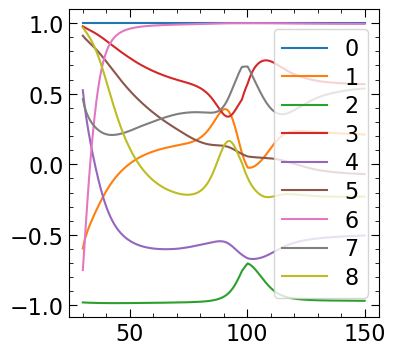

In [6]:
# Use_Basis = np.array([0,1,3,5,7,8]) 
Use_Basis = np.arange(9)
N_Basis = len(Use_Basis)

print('Using {0:d} basis functions:'.format(N_Basis))
print(Use_Basis)

# read setup parameters
with open(Basis_Stem + '.pkl', 'rb') as f:
    params_setup = pickle.load(f)    
params_setup['file_stem'] = Basis_Stem
# initialize class
binet = BiSequential(params=params_setup)
# load network parameters from files
binet.load()

rvals = np.linspace(30,150,500)

basis = binet.extract_basis()
basis_func = basis.predict(binet.rv(rvals))
basis_func = np.concatenate((np.ones((1,basis_func.shape[1])),basis_func),axis=0) 
basis_func = basis_func[Use_Basis]

plt.figure(figsize=(4,4))
for b in range(N_Basis):
    plt.plot(rvals,basis_func[b],label=str(Use_Basis[b]))
plt.minorticks_on()
plt.legend()
plt.show()

### Info dictionary

#### Basic definition

In [10]:
Modify_Data = True # default True

Accuracy = 'mid' # 'low','mid' or 'high'. Default 'mid', giving <~3% error on quadrupole

id_str = Sample_Root + Sample + '/mcmc' + File_Body
if Include_Sig2Obs:
    id_str += '_inclSig2obs'
if not Modify_Data:
    id_str += '_unmod'
if Accuracy != 'mid':
    id_str += '_'+Accuracy+'acc'
if L_Max < 3:
    id_str += '_LMax{0:d}'.format(L_Max)
    
W_Names = ['w_{0:d}'.format(m) for m in Use_Basis] 

Params_List = ['beta','sigv']
Latex_List = ['\\beta','\\sigma_{\\rm v}']

Params_List.extend(W_Names)
Latex_List.extend(W_Names)

Params_List += ['b','B1st','Bvst','sigma','AMC']
Latex_List += ['b','B_{1\\ast}','B_{v\\ast}','\\sigma','A_{\\rm MC}']

if L_Max > 1:
    Params_List += ['qbar2']
    Latex_List += ['\\bar q^{(2)}']
    if L_Max == 3:
        Params_List += ['qbar4']
        Latex_List += ['\\bar q^{(4)}']

if Include_Sig2Obs:
    Params_List += ['fv']
    Latex_List += ['f_{\\rm v}']

if Model_AP:
    Params_List += ['Daiso','DaAP']
    Latex_List += ['\\Delta\\alpha_{\\rm iso}','\\Delta\\alpha_{\\rm AP}']

info = {}
info['likelihood'] = {'zelsmear.ZeldovichSmearingLike':
                      {'python_path':Like_Dir,
                       'L_Max':L_Max,
                       'modify_data':Modify_Data,
                       'include_Sig2obs':Include_Sig2Obs,
                       'scales_file':Scales_File,
                       'data_file':Data_File,
                       'cov_file':Cov_File
                      }}

info['theory'] = {'zelsmear.ZeldovichSmearingTheory':
                  {'python_path':Like_Dir,
                   'stop_at_error': True,
                   'use_basis': Use_Basis,
                   'basis_stem':Basis_Stem,
                   'accuracy':Accuracy,
                   'n_r':100, 
                   # 100 gives LP convergence error ~0.1%, i.e. 3x smaller than DESI expectation
                   # 300 gives ~0.03%, 1000 is converged
                   'scales_file':Scales_File,
                   'L_Max':L_Max,
                   'modify_data':Modify_Data,
                   'model_AP':Model_AP,
                   'include_Sig2obs':Include_Sig2Obs
                  }}

#### Set evaluation values

In [11]:
# Change values while preserving list structure to play with theoretical predictions
Defaults_List = [beta_fid,sigv_fid]
for w in range(len(W_Names)):
    Defaults_List.append((b_fid*growth_fid)**2*basis_prior[str(w)][0])

Defaults_List += [b_fid,B1st_fid,Bvst_fid,sigma_fid,AMC_fid] 

if L_Max > 1:
    Defaults_List += [qbar2_fid] 
    if L_Max == 3:
        Defaults_List += [0.0] 

if Include_Sig2Obs:
    Defaults_List += [fv_fid]  

if Model_AP:
    Defaults_List += [Daiso_fid,DaAP_fid]  


#### Set defaults

In [12]:
info['params'] = {}
for p in range(len(Params_List)):
    param = Params_List[p]
    defval = Defaults_List[p]
    
    info['params'][param] = {'latex':Latex_List[p]}
    if param == 'AMC':
        info['params'][param] = {'latex':Latex_List[p]}
    if (param == 'qbar2'):
        if Modify_Data & (L_Max == 2):
            info['params'][param] = defval
        else:
            info['params'][param] = {'latex':Latex_List[p]}
    if (param == 'qbar4'):
        if Modify_Data:
            info['params'][param] = defval                
        else:
            info['params'][param] = {'latex':Latex_List[p]}

#### Set priors (values irrelevant)

In [13]:
info['params']['beta']['prior'] = {'min':-1.0,'max':1.0} 
info['params']['sigv']['prior'] = {'min':0.0,'max':12.0}

for w in range(len(W_Names)):
    wname = W_Names[w]
    w_mean,w_std = basis_prior[str(w)][0],basis_prior[str(w)][1]
    w_mean *= (b_fid*growth_fid)**2
    w_std *= (b_fid*growth_fid)**2
    info['params'][wname]['prior'] = {'dist':'norm','loc':w_mean,'scale':w_std} 
    
info['params']['b']['prior'] =  {'dist':'norm','loc':b_fid,'scale':0.01*np.fabs(b_fid)}

info['params']['B1st']['prior'] = {'min':-100.0,'max':100.0}
info['params']['Bvst']['prior'] = {'min':-100.0,'max':100.0}
info['params']['sigma']['prior'] = {'min':0.0,'max':12.0} 
info['params']['AMC']['prior'] = {'dist':'norm','loc':0.0,'scale':0.05}

if L_Max > 1:
    if (not Modify_Data) | (L_Max == 3):
        # note L_Max==3 not 2
        info['params']['qbar2']['prior'] = {'min':-2.0,'max':2.0}
    if (L_Max == 3) & (not Modify_Data):
        info['params']['qbar4']['prior'] = {'min':-2.0,'max':2.0}
if Include_Sig2Obs:
    info['params']['fv']['prior'] = {'dist':'norm','loc':fv_fid,'scale':0.01*np.fabs(fv_fid)}

if Model_AP:
    info['params']['Daiso']['prior'] = {'dist':'norm','loc':Daiso_fid,'scale':0.01*np.fabs(Daiso_fid)}
    info['params']['DaAP']['prior'] = {'dist':'norm','loc':DaAP_fid,'scale':0.01*np.fabs(DaAP_fid)}

### Model evaluation

Setting up 20,6 layer feed-forward bi-neural network
... ... expecting data dim = 1, theta dim = 2, output dim = 1
... ... NNa using hidden layers of sizes [8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8]
... ... ... and activations [relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,tanh,tanh,tanh,tanh,tanh]
... ... NNw using hidden layers of sizes [3,3,3,3,3,9]
... ... ... and activations [tanh,tanh,tanh,tanh,tanh,tanh]
... ... using loss function 'square'
... ... not using any regularization
... ... not using any weight decay in NNa
... ... not using any weight decay in NNw
Extracting basis functions as NN...
... extracting basis functions from NNa
... setting up 20 layer feed-forward neural network
Warning!: last activation tanh seems inconsistent with square loss. Proceed with caution!
... ... expecting data dim = 1, target dim = 8
... ... using hidden layers of sizes [8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8]
... ... ... and activations [relu,relu,relu,relu,relu,rel

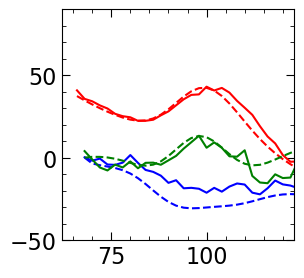

Sig2obs:
...  data: [27.36979  10.91015  -2.260048]
... error: [0.2495858 0.9588902 1.249472 ]
... model: [27.88236911 11.98201952  0.63689019]


In [14]:
# set up calculators
model = get_model(info)
like = model.likelihood['zelsmear.ZeldovichSmearingLike']
theory = model.theory['zelsmear.ZeldovichSmearingTheory']

# make model prediction
dp_test = {Params_List[p]:Defaults_List[p] for p in range(len(Params_List))}
point = dict(zip(model.parameterization.sampled_params(),
                 model.prior.sample(ignore_external=True)[0]))
point.update({key:dp_test[key] for key in point.keys()})
print(model.logposterior(point))
xiNLell = model.provider.get_model() # outputs flat array
# below needed in case like.rescale was set different from unity
# xiNLell *= like.rescale 
# if Include_Sig2Obs:
#     xiNLell[:L_Max] /= like.rescale # Sig2's not rescaled

# load data
if Include_Sig2Obs:
    data = np.concatenate((np.loadtxt(Data_File[0]).T[0],np.loadtxt(Data_File[1])))
else:
    data = np.loadtxt(Data_File)
cov_data = np.loadtxt(Cov_File)
data,cov_data = like.organize_data(data,cov_data)
print(xiNLell.shape,data.shape,cov_data.shape)

# compare data with model
residual = data - xiNLell
z = linalg.cho_solve((like.L,True),residual) # solves (L L^T) z = residual or z = C^-1 residual
chi2 = np.dot(residual,z)
print('chi2: {0:.1f}'.format(chi2))

# plot stuff
# ... first reshape to segregate multipoles and Sig2 vs xi(s)
xiNLell = like.wrap_model(xiNLell)
data = like.wrap_model(data)
# print('wrapped model:',xiNLell)
# print('wrapped data:',data)

plt.figure(figsize=(3,3))
plt.xlim(62,123)
if Modify_Data:
    plt.ylim(-50,90)
else:
    plt.ylim(-120,120)
off = 1 if Modify_Data else 0
offset = 1 if Include_Sig2Obs else 0
plt.plot(theory.svals,theory.svals**2*data[offset],'r-')
plt.plot(theory.svals,theory.svals**2*xiNLell[offset],'r--')
if L_Max > 1:
    plt.plot(theory.svals[off:],theory.svals[off:]**2*data[offset+1],'b-')
    plt.plot(theory.svals[off:],theory.svals[off:]**2*xiNLell[offset+1],'b--')
    if L_Max == 3:
        plt.plot(theory.svals[off:],theory.svals[off:]**2*data[offset+2],'g-')
        plt.plot(theory.svals[off:],theory.svals[off:]**2*xiNLell[offset+2],'g--')
plt.minorticks_on()
plt.show()

if Include_Sig2Obs:
    print('Sig2obs:')
    print('...  data:',data[0])
    print('... error:',np.sqrt(np.diag(cov_data)[:L_Max]))
    print('... model:',xiNLell[0])

### Auxiliary functions

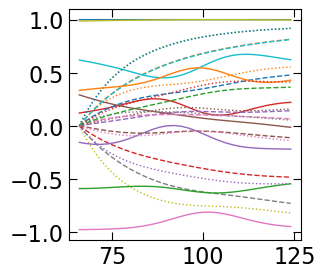

In [15]:
# calculate and plot smoothed basis \lambda_m, \bar \lambda_m, \bar\bar \lambda_m
lam = theory.calc_lambda(sigma_fid)
if L_Max > 1:
    lam_b,lam_bb = theory.calc_lambda_bars(sigma_fid)
plt.figure(figsize=(3,3))
for b in range(N_Basis):
    plt.plot(theory.svals,lam[b],lw=1,ls='-',label=str(Use_Basis[b]))
    if L_Max > 1:
        plt.plot(theory.svals,lam_b[b],lw=1,ls='--')
        if L_Max == 3:
            plt.plot(theory.svals,lam_bb[b],lw=1,ls=':')
# plt.legend()
plt.show()